# Exploratory Data Anaylsis

In this notebook, we conduct the following steps:

1. Import libraries and load data
2. Initial data inspection
3. Raw time series visualization
4. Distribution and rolling statistics
5. Seasonal decomposition
6. Correlation analysis
7. ACF/PACF analysis
8. Stationarity testing (ADF)

### Step 1: Import Libraries and Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
import os

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

# 1. Update this path to the folder where your CSVs are located
# If they are in the same folder as this notebook, leave it as './'
data_path = 'Data/' 

# File configuration: Mapping CSV filenames to their internal variable names
files_config = {
    'FEDFUNDS.csv': 'FEDFUNDS',
    'ICSA.csv': 'ICSA',
    'INDPRO.csv': 'INDPRO',
    'PAYEMS.csv': 'PAYEMS',
    'RRSFS.csv': 'RRSFS',
    'UNRATENSA (1).csv': 'UNRATENSA'
}

def load_and_merge_local(path):
    """Reads local CSV files and merges them into a consistent monthly dataframe."""
    dfs = []
    
    for filename, colname in files_config.items():
        full_path = os.path.join(path, filename)
        
        if not os.path.exists(full_path):
            print(f"Warning: {filename} not found in {path}")
            continue
            
        # Read directly from local disk
        df = pd.read_csv(full_path)
        df['observation_date'] = pd.to_datetime(df['observation_date'])

        # Initial Claims (ICSA) is weekly; resample to Month-Start (MS) sum
        if colname == 'ICSA':
            df = df.set_index('observation_date').resample('MS').sum().reset_index()
        dfs.append(df)

    if not dfs:
        raise FileNotFoundError("No CSV files were found. Check your file paths.")

    # Merge all datasets on 'observation_date'
    df_merged = dfs[0]
    for i in range(1, len(dfs)):
        df_merged = pd.merge(df_merged, dfs[i], on='observation_date', how='outer')

    # Standardize index and interpolate any gaps
    df_merged = df_merged.sort_values('observation_date').set_index('observation_date')
    df_merged = df_merged.interpolate(method='linear')
    return df_merged

# Execute processing
data = load_and_merge_local(data_path)
print(f"\nProcessing Complete. Range: {data.index.min().date()} to {data.index.max().date()}")
print(data.head())



Processing Complete. Range: 1919-01-01 to 2026-02-01
                  FEDFUNDS  ICSA  INDPRO  PAYEMS  RRSFS  UNRATENSA
observation_date                                                  
1919-01-01             NaN   NaN  4.8739     NaN    NaN        NaN
1919-02-01             NaN   NaN  4.6585     NaN    NaN        NaN
1919-03-01             NaN   NaN  4.5238     NaN    NaN        NaN
1919-04-01             NaN   NaN  4.6046     NaN    NaN        NaN
1919-05-01             NaN   NaN  4.6315     NaN    NaN        NaN



### Step 2: Initial Data Inspection

We will examine our data structure (shapes, dtypes, missing values) and ensure the datetime index is properly formatted.




In [4]:
data.reset_index().head()

,observation_date,FEDFUNDS,ICSA,INDPRO,PAYEMS,RRSFS,UNRATENSA
0,1919-01-01,NaN,NaN,4.8739,NaN,NaN,NaN
1,1919-02-01,NaN,NaN,4.6585,NaN,NaN,NaN
2,1919-03-01,NaN,NaN,4.5238,NaN,NaN,NaN
3,1919-04-01,NaN,NaN,4.6046,NaN,NaN,NaN
4,1919-05-01,NaN,NaN,4.6315,NaN,NaN,NaN


In [5]:
print("\nShape:")
print(data.shape)

print("\nColumns:")
print(list(data.columns))

print("\nData types:")
print(data.dtypes)

print("\nMissing values by column:")
print(data.isnull().sum())

print("\nRows with any missing values:")
print(data.isnull().any(axis=1).sum())

print("\nDuplicate timestamp count:")
print(data.index.duplicated().sum())

print("\nDate index check:")
print(f"Index type: {type(data.index)}")
print(f"Start date: {data.index.min().date()}")
print(f"End date  : {data.index.max().date()}")



Shape:
(1286, 6)

Columns:
['FEDFUNDS', 'ICSA', 'INDPRO', 'PAYEMS', 'RRSFS', 'UNRATENSA']

Data types:
FEDFUNDS     float64
ICSA         float64
INDPRO       float64
PAYEMS       float64
RRSFS        float64
UNRATENSA    float64
dtype: object

Missing values by column:
FEDFUNDS     426
ICSA         576
INDPRO         0
PAYEMS       240
RRSFS        876
UNRATENSA    348
dtype: int64

Rows with any missing values:
876

Duplicate timestamp count:
0

Date index check:
Index type: <class 'pandas.DatetimeIndex'>
Start date: 1919-01-01
End date  : 2026-02-01


#### Analysis

The merged dataset contains 1,286 monthly obersvations across six macroeconomics variables related to unemploymnet.

The dataset begins on 1919-01-01 and ends on 2026-02-01, with no duplicate timestamps, 876 rows containing at least one missing values, and a number of missing values by column.


### Step 3: Visualization

We will plot the raw time series and understand scale, trends, and patterns. We will create multiple views of the full series, zoomed sections, and year-over-year. We will plot seasonal decomposition (trend, seasonal, residual components)






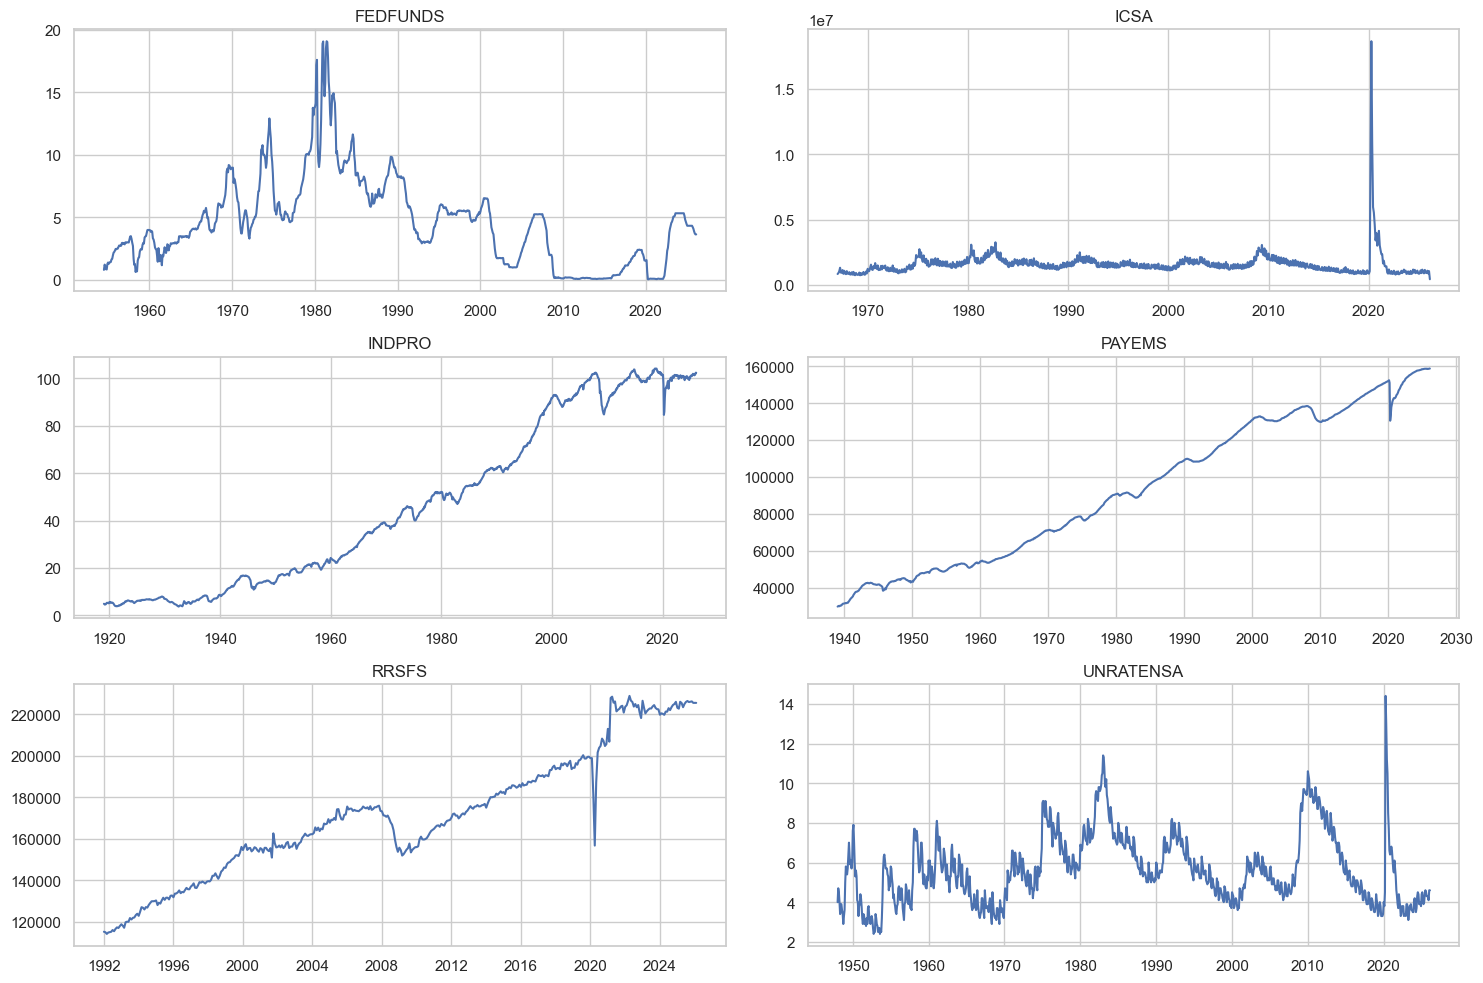

In [6]:
series_cols = ['FEDFUNDS', 'ICSA', 'INDPRO', 'PAYEMS', 'RRSFS', 'UNRATENSA']

plt.figure(figsize=(15, 10))
for i, col in enumerate(series_cols, 1):
    plt.subplot(3, 2, i)
    plt.plot(data.index, data[col])
    plt.title(col)
    plt.grid(True)

plt.tight_layout()
plt.show()

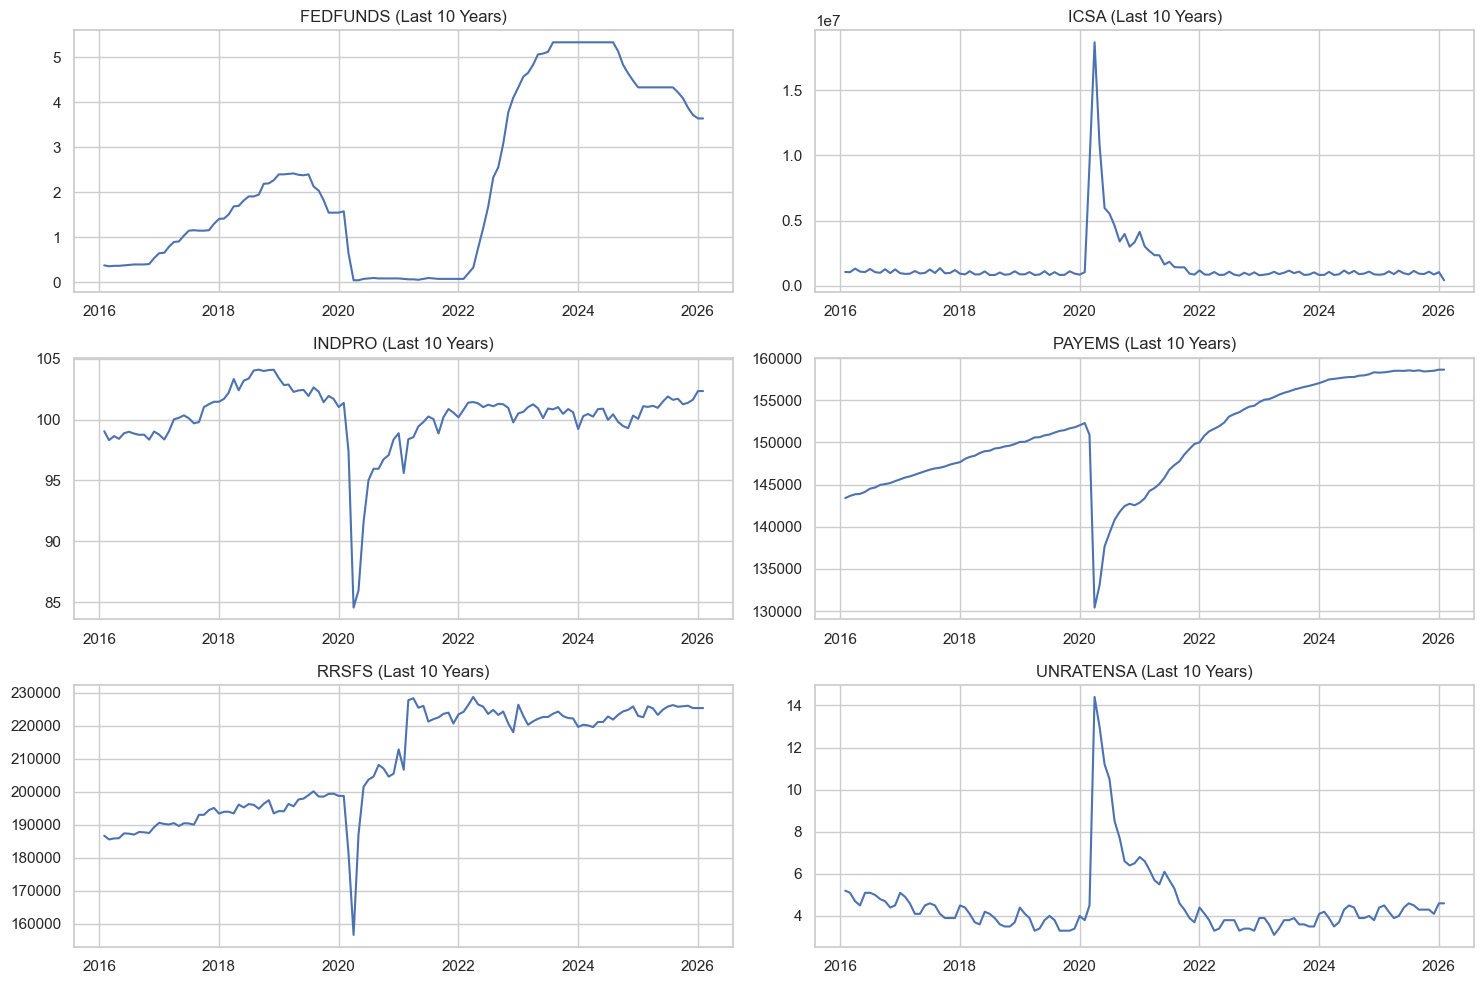

In [7]:
zoom_start = data.index.max() - pd.DateOffset(years=10)
data_zoom = data.loc[zoom_start:].copy()

plt.figure(figsize=(15, 10))
for i, col in enumerate(series_cols, 1):
    plt.subplot(3, 2, i)
    plt.plot(data_zoom.index, data_zoom[col])
    plt.title(f"{col} (Last 10 Years)")
    plt.grid(True)
plt.tight_layout()
plt.show()

#### Analysis


The two views provide different perspectives into the different macroeconomic indicators.

The first and longer view provides useful information about each macroeconomic indicatior. INDPRO, RRSFS, and PAYEMS have shown long term upward trends since their inception. The FEDFUNDS has demonstranted cyclical behavior and the UNRATENSA has shown many dips and spikes throughout its span. ICSA has remained relatively stable with a spike in 2020, however, we will consider COVID to be an anonomaly in our modeling approach.  


The second view provides more support in including exogenous variables in our modeling approach. There seem to be synchronized movements relative to UNRATENSA and the other macroeconomic indicators.

This initial analysis of the macroeconomic indicators and UNRATENSA provide support for a time series modeling approach that includes exogenous variables.


### Step 4: Distribution and rolling statistics

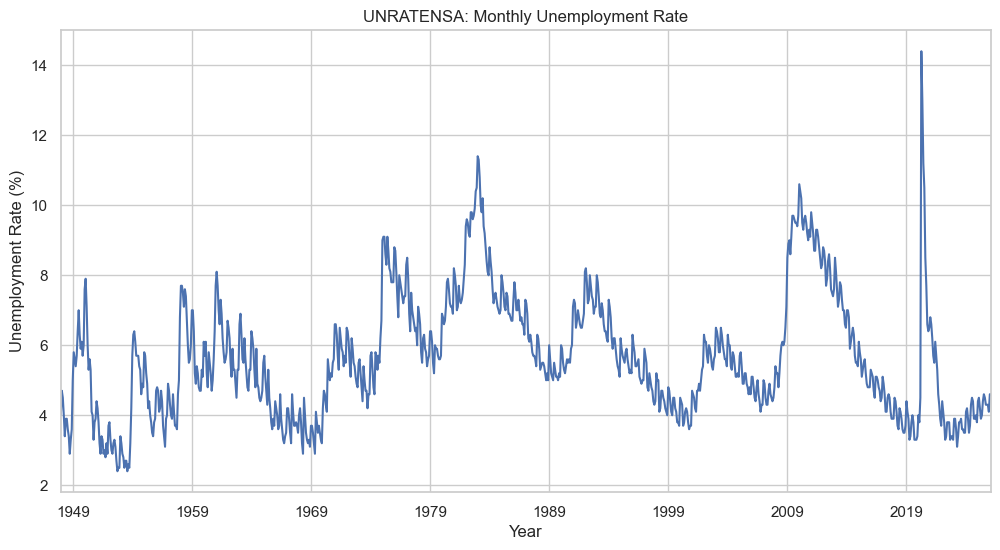

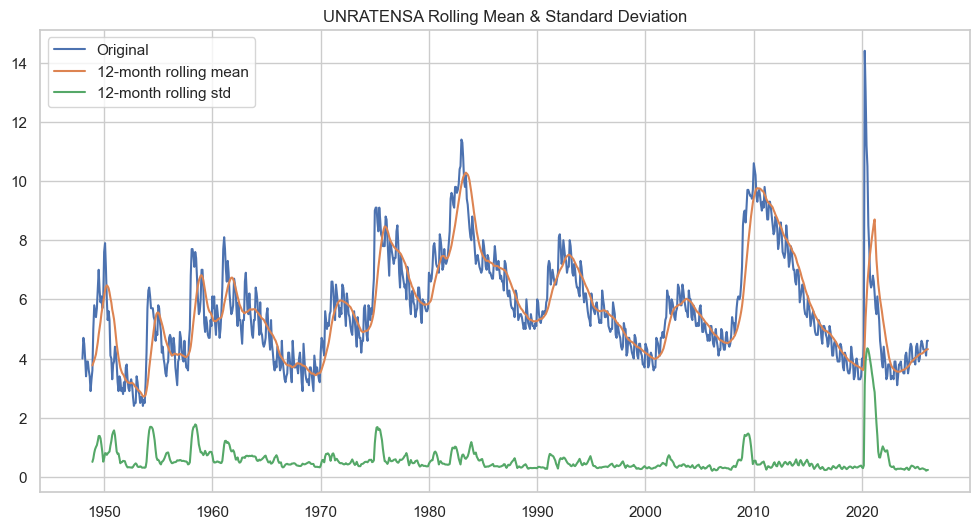

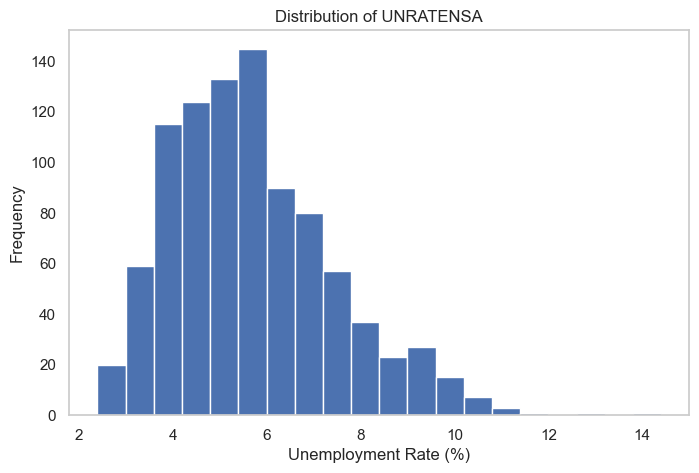

In [8]:
ts = data['UNRATENSA'].dropna()

ts.plot(figsize=(12,6))
plt.title("UNRATENSA: Monthly Unemployment Rate")
plt.ylabel("Unemployment Rate (%)")
plt.xlabel("Year")
plt.grid(True)
plt.show()

rolling_mean = ts.rolling(window=12).mean()
rolling_std = ts.rolling(window=12).std()

plt.figure(figsize=(12,6))
plt.plot(ts, label="Original")
plt.plot(rolling_mean, label="12-month rolling mean")
plt.plot(rolling_std, label="12-month rolling std")

plt.title("UNRATENSA Rolling Mean & Standard Deviation")
plt.legend()
plt.grid(True)
plt.show()

ts.hist(bins=20, figsize=(8,5))

plt.title("Distribution of UNRATENSA")
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Frequency")
plt.grid(False)

plt.show()

#### Analysis

Examining the monthly unemployment rate more closesly, we can see that there is a cyclical pattern that reflects economic expansion and contraction. Periods of economic conflict resulted in spikes in unemplotyment while periods of economic stability resulted in dips in unemployment. It is important to note that we will be considering COVID to be an anamoly and omit it from our modeling approach.

The 12-month rolling mean

### Step 5: Seasonal decomposition

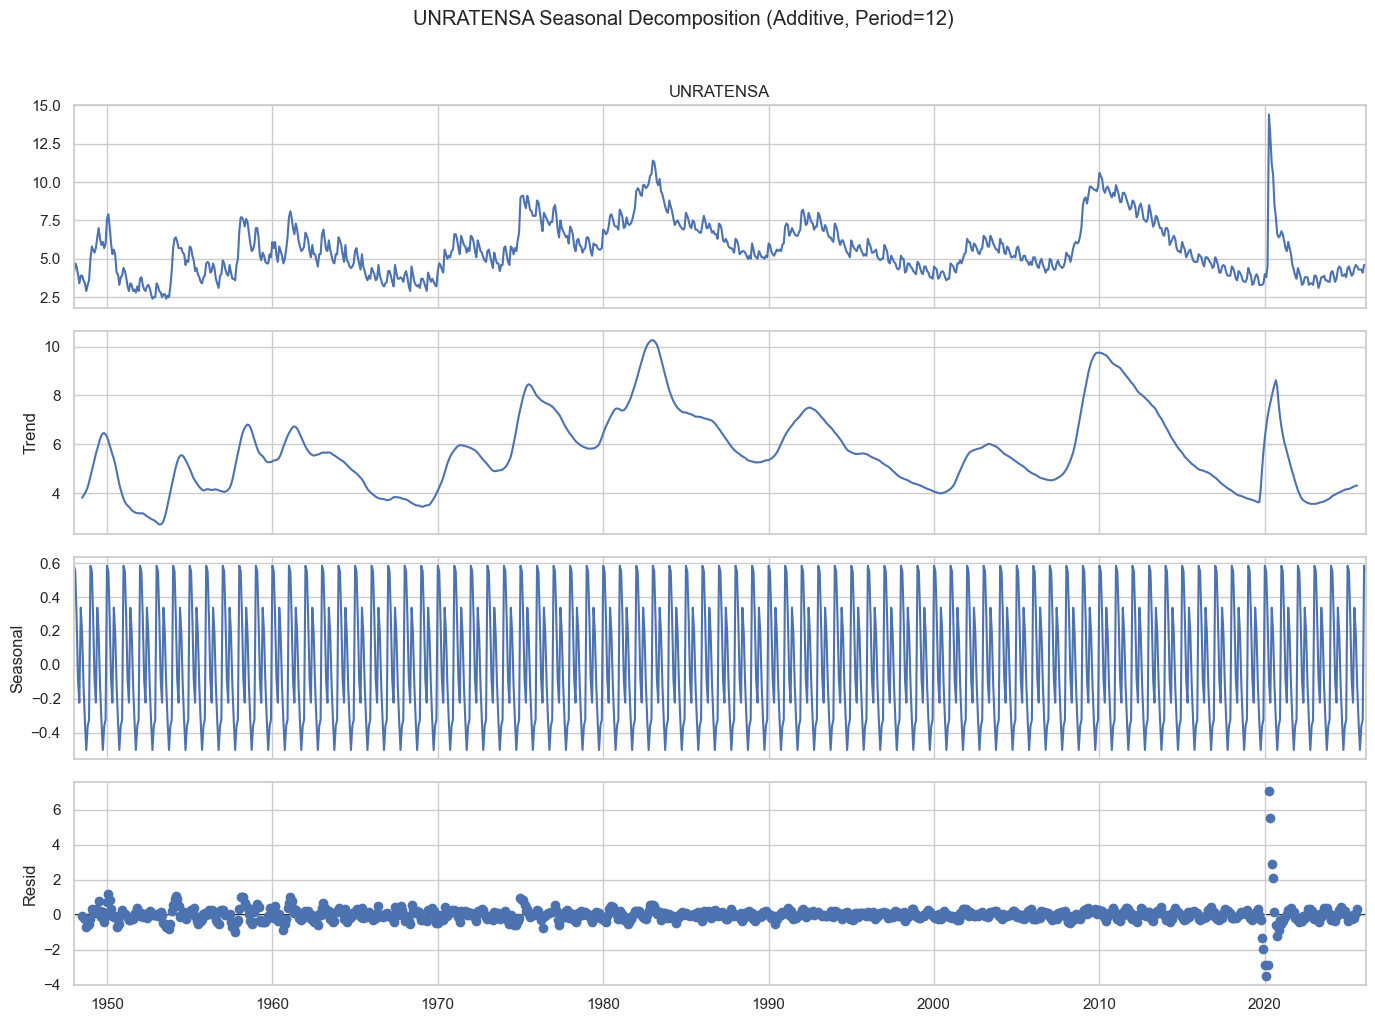

In [9]:
from statsmodels.tsa.seasonal import seasonal_decompose

unemployment = data['UNRATENSA'].dropna()

decomp = seasonal_decompose(unemployment, model='additive', period=12)
fig = decomp.plot()
fig.set_size_inches(14, 10)
plt.suptitle("UNRATENSA Seasonal Decomposition (Additive, Period=12)", y=1.02)
plt.tight_layout()
plt.show()

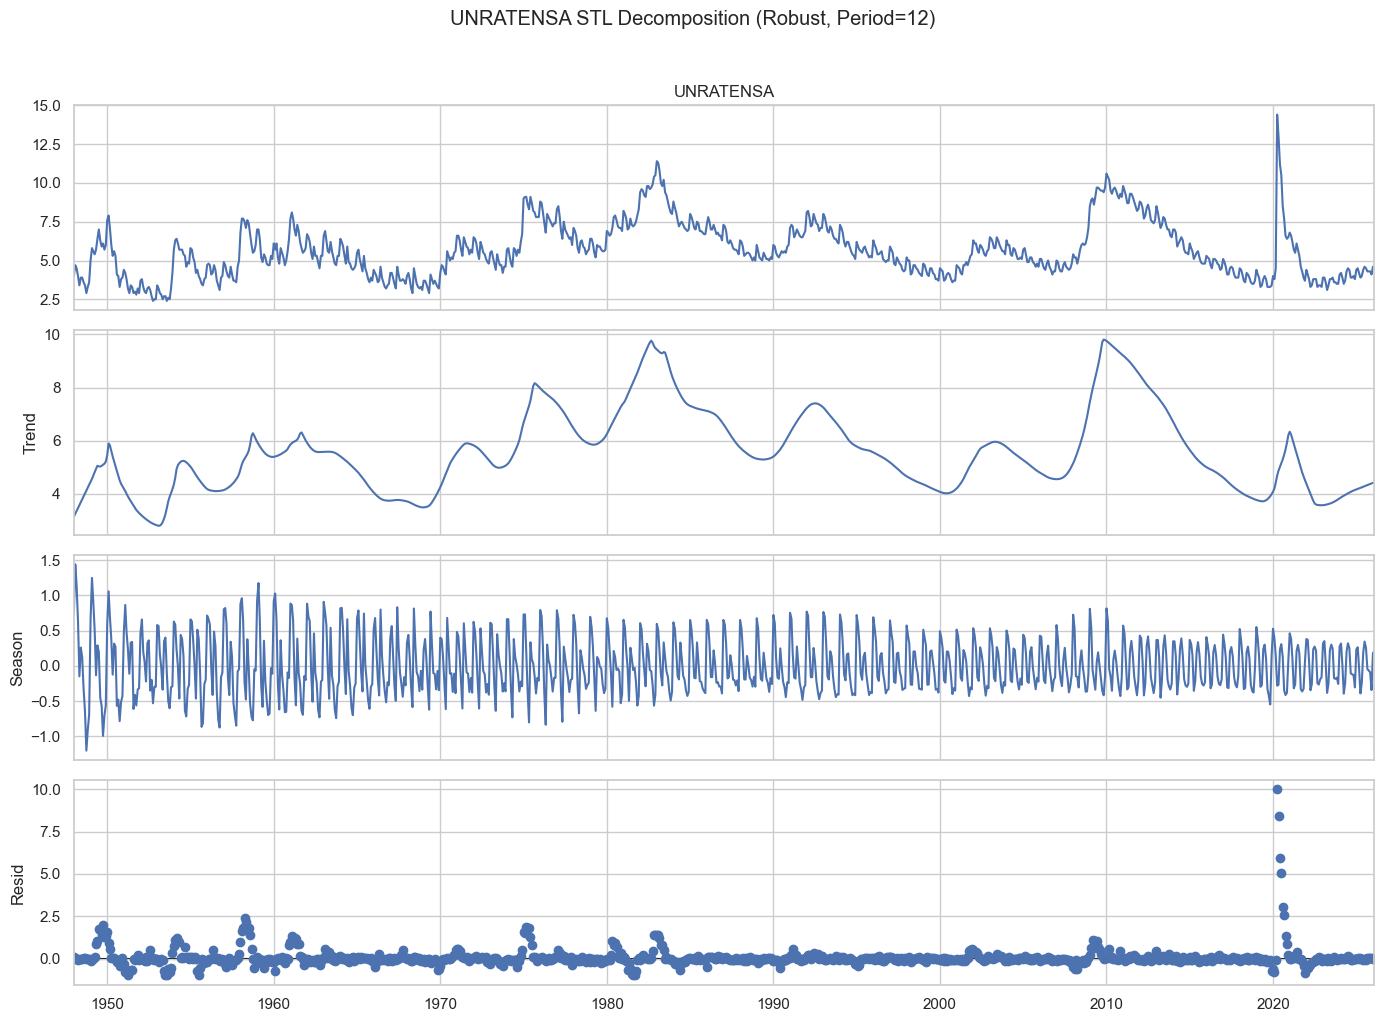

In [10]:
stl = STL(unemployment, period=12, robust=True)
res = stl.fit()
fig = res.plot()
fig.set_size_inches(14, 10)
plt.suptitle("UNRATENSA STL Decomposition (Robust, Period=12)", y=1.02)
plt.tight_layout()
plt.show()

### Step 6: Correlation Analysis

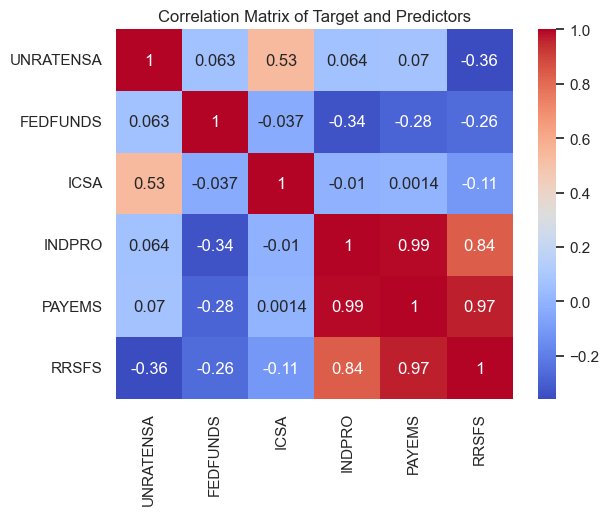

In [11]:
corr = data[['UNRATENSA','FEDFUNDS','ICSA','INDPRO','PAYEMS','RRSFS']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix of Target and Predictors")
plt.show()

In [12]:
## ADF Testing:
from statsmodels.tsa.stattools import adfuller

# Drop missing values just in case
series = data['UNRATENSA'].dropna()

# Run ADF test
adf_result = adfuller(series)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Number of lags used:", adf_result[2])
print("Number of observations:", adf_result[3])

print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -2.926803870286079
p-value: 0.042318680185001026
Number of lags used: 22
Number of observations: 915

Critical Values:
1%: -3.437516929214992
5%: -2.86470390726455
10%: -2.5684546666069457


**borderline stationarity**

### Step 7: ACF/PACF Analysis

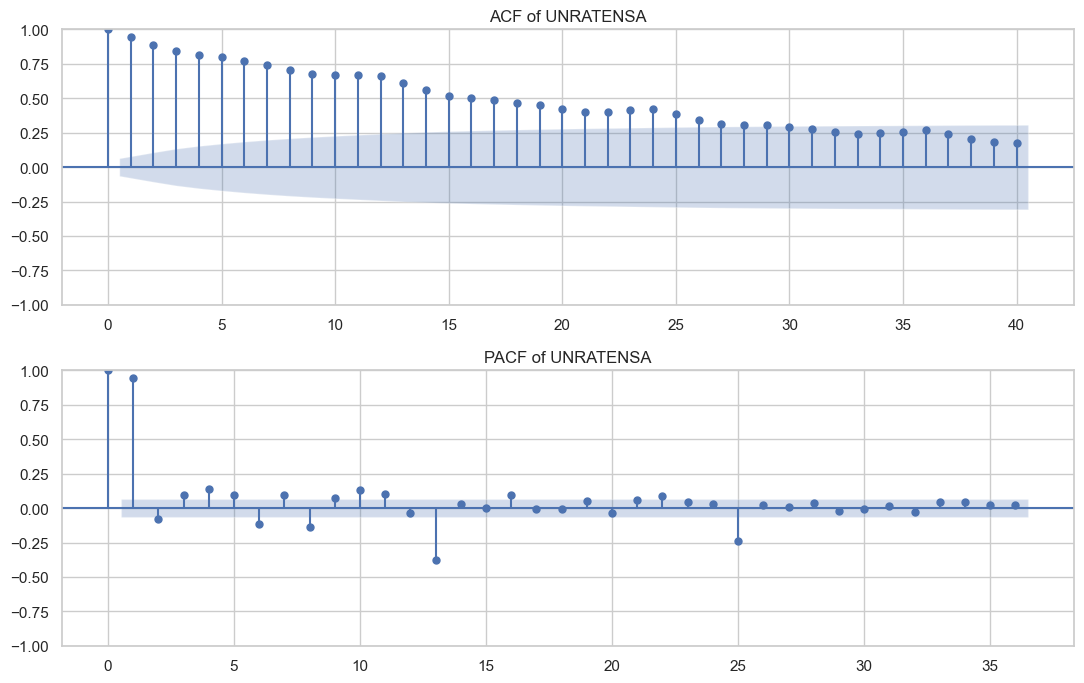

In [13]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

ts = data['UNRATENSA'].dropna()

fig, axes = plt.subplots(2, 1, figsize=(11, 7))

plot_acf(ts, lags=40, ax=axes[0])
axes[0].set_title("ACF of UNRATENSA")

plot_pacf(ts, lags=36, ax=axes[1])
axes[1].set_title("PACF of UNRATENSA")

plt.tight_layout()
plt.show()

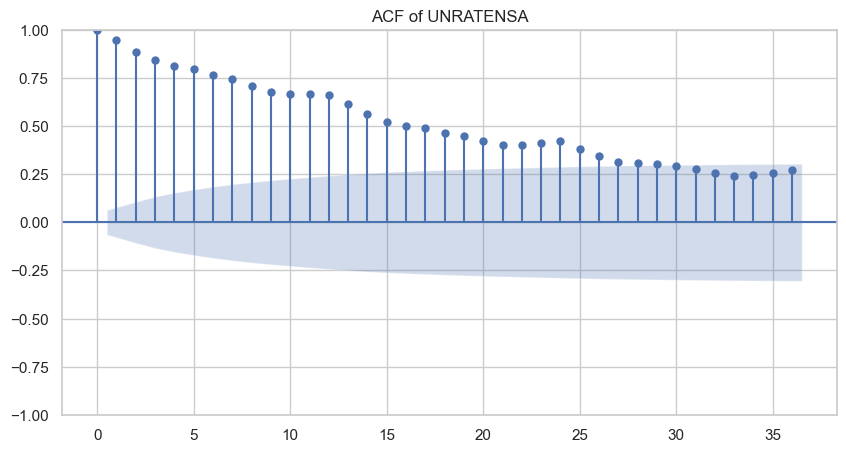

Autocorrelation at lag 12: 0.6705821903109558
Autocorrelation at lag 24: 0.427484565052862
Autocorrelation at lag 36: 0.27849563064640714


In [14]:
## ACF at lag 12
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

# target series
series = data["UNRATENSA"].dropna()

# plot ACF up to 36 lags so we can inspect lag 12 clearly
fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(series, lags=36, ax=ax)
ax.set_title("ACF of UNRATENSA")
plt.show()

# print the exact autocorrelation values too
acf_lag_12 = series.autocorr(lag=12)
acf_lag_24 = series.autocorr(lag=24)
acf_lag_36 = series.autocorr(lag=36)

print("Autocorrelation at lag 12:", acf_lag_12)
print("Autocorrelation at lag 24:", acf_lag_24)
print("Autocorrelation at lag 36:", acf_lag_36)

# Modeling hypothesis:
We will build baseline models of Naive model, seasonal Naive model, and SARIMA model. 

In [15]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
## Naive model
# already defined before
y = data["UNRATENSA"].dropna()

train = y.iloc[:-12]
test = y.iloc[-12:]

# -----------------
# Naive forecast
# -----------------
naive_forecast = np.repeat(train.iloc[-1], 12)

naive_forecast = np.array(naive_forecast)

# metrics
mae_naive = mean_absolute_error(test, naive_forecast)
rmse_naive = np.sqrt(mean_squared_error(test, naive_forecast))
mape_naive = np.mean(np.abs((test - naive_forecast) / test)) * 100

print("Naive Model")
print("MAE :", mae_naive)
print("RMSE:", rmse_naive)
print("MAPE:", mape_naive)

Naive Model
MAE : 0.23333333333333328
RMSE: 0.2915475947422651
MAPE: 5.627627071975266


In [16]:
# -----------------
# Seasonal naive
# -----------------
seasonal_naive_forecast = train.iloc[-12:].values

mae_snaive = mean_absolute_error(test, seasonal_naive_forecast)
rmse_snaive = np.sqrt(mean_squared_error(test, seasonal_naive_forecast))
mape_snaive = np.mean(np.abs((test - seasonal_naive_forecast) / test)) * 100

print("\nSeasonal Naive Model")
print("MAE :", mae_snaive)
print("RMSE:", rmse_snaive)
print("MAPE:", mape_snaive)


Seasonal Naive Model
MAE : 0.24999999999999986
RMSE: 0.276887462097269
MAPE: 5.9156947989749


### Why seasonal is worst?
Because unemployment in your holdout period is driven more by short-run persistence than by repeating the exact value from the same month last year. Seasonal naive uses only lag 12, while SARIMA captures both lag 1 persistence and seasonal structure. In your data, that combination matters more than pure seasonality.

### SARIMAX Model

Train period: 1948-01-01 00:00:00 to 2025-02-01 00:00:00
Test period : 2025-03-01 00:00:00 to 2026-02-01 00:00:00
Train size: 926
Test size : 12
                                     SARIMAX Results                                      
Dep. Variable:                          UNRATENSA   No. Observations:                  926
Model:             SARIMAX(1, 0, 0)x(1, 0, 0, 12)   Log Likelihood                -675.765
Date:                            Thu, 12 Mar 2026   AIC                           1357.530
Time:                                    17:31:49   BIC                           1371.980
Sample:                                01-01-1948   HQIC                          1363.046
                                     - 02-01-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------

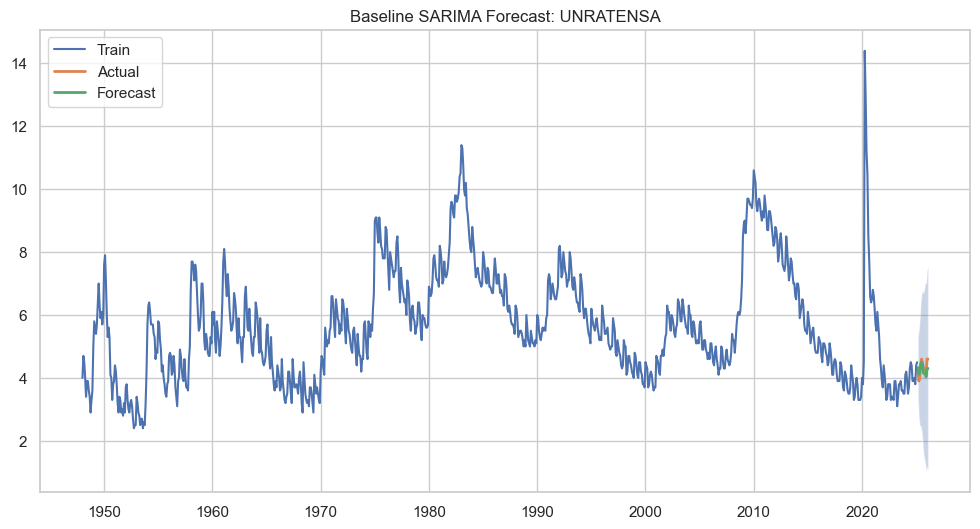

In [18]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# ----------------------------
# 1. Prepare target series
# ----------------------------
y = data["UNRATENSA"].dropna().copy()

# 12-month holdout
train = y.iloc[:-12]
test = y.iloc[-12:]

print("Train period:", train.index.min(), "to", train.index.max())
print("Test period :", test.index.min(), "to", test.index.max())
print("Train size:", len(train))
print("Test size :", len(test))

# ----------------------------
# 2. Fit SARIMA baseline
# ----------------------------
sarima_model = SARIMAX(
    train,
    order=(1, 0, 0),
    seasonal_order=(1, 0, 0, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit(disp=False)

print(sarima_result.summary())

# ----------------------------
# 3. Forecast next 12 months
# ----------------------------
forecast = sarima_result.get_forecast(steps=12)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

# align forecast index to test index
forecast_mean.index = test.index
forecast_ci.index = test.index

# ----------------------------
# 4. Evaluate accuracy
# ----------------------------
mae = mean_absolute_error(test, forecast_mean)
rmse = np.sqrt(mean_squared_error(test, forecast_mean))
mape = np.mean(np.abs((test - forecast_mean) / test)) * 100

print("\nBaseline SARIMA Forecast Accuracy")
print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.2f}%")

# ----------------------------
# 5. Plot forecast vs actual
# ----------------------------
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual", linewidth=2)
plt.plot(forecast_mean.index, forecast_mean, label="Forecast", linewidth=2)
plt.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    alpha=0.3
)
plt.title("Baseline SARIMA Forecast: UNRATENSA")
plt.legend()
plt.show()

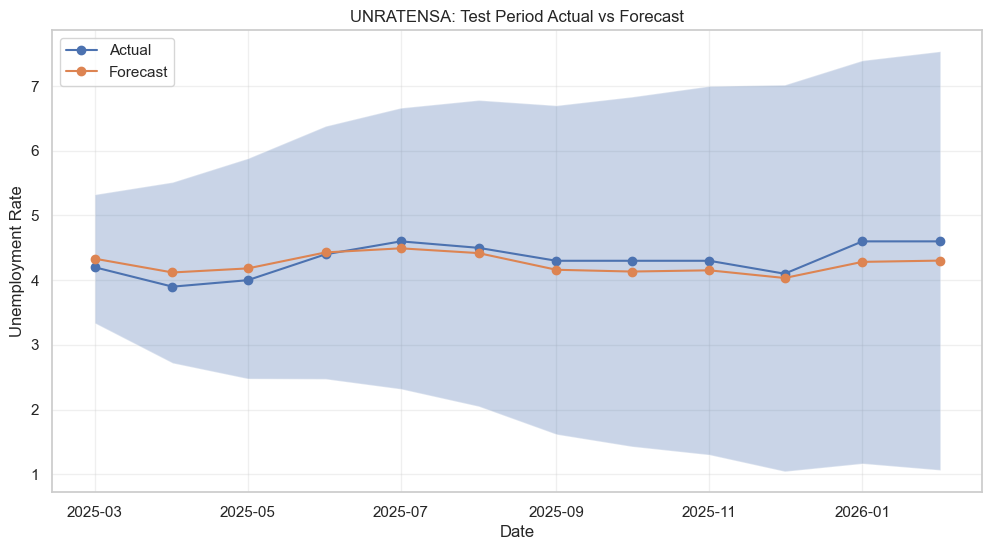

In [19]:
# Plot only the test period vs forecast
plt.figure(figsize=(12, 6))
plt.plot(test.index, test, label="Actual", marker="o")
plt.plot(forecast_mean.index, forecast_mean, label="Forecast", marker="o")
plt.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    alpha=0.3
)
plt.title("UNRATENSA: Test Period Actual vs Forecast")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

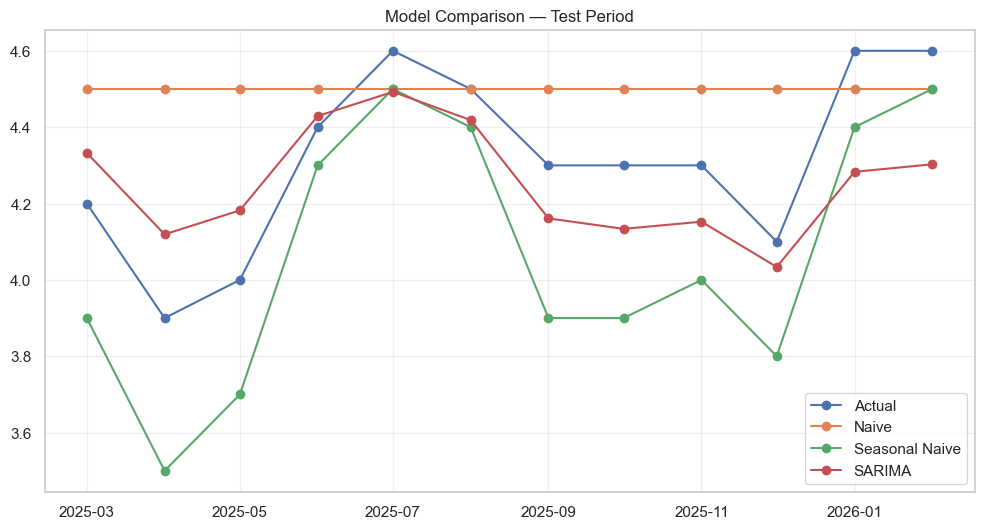

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(test.index, test, label="Actual", marker="o")

plt.plot(test.index, naive_forecast, label="Naive", marker="o")

plt.plot(test.index, seasonal_naive_forecast,
         label="Seasonal Naive", marker="o")

plt.plot(test.index, forecast_mean,
         label="SARIMA", marker="o")

plt.title("Model Comparison — Test Period")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [21]:
results = {
    "Model": ["Naive", "Seasonal Naive", "SARIMA"],
    "MAE": [mae_naive, mae_snaive, mae],
    "RMSE": [rmse_naive, rmse_snaive, rmse],
    "MAPE": [mape_naive, mape_snaive, mape],
}

import pandas as pd

results_df = pd.DataFrame(results)

print(results_df)

            Model       MAE      RMSE      MAPE
0           Naive  0.233333  0.291548  5.627627
1  Seasonal Naive  0.250000  0.276887  5.915695
2          SARIMA  0.157080  0.177891  3.635925


The SARIMA(1,0,0)(1,0,0)_{12} model outperformed both naive and seasonal naive benchmarks, reducing RMSE from 0.29 to 0.18 and MAPE from ~5.6% to ~3.6%. This indicates that the unemployment rate contains both autoregressive and seasonal structure that cannot be captured by simple persistence models.

#### Was our first SARIMAX Multi variant mode? 
Yes, but the better term is multivariate exogenous time-series model or SARIMAX with exogenous predictors. It is not a full multivariate system like VAR, because only unemployment is modeled as the dependent series and the other variables enter as exogenous regressors.

In [22]:
data.notna().idxmax()

FEDFUNDS    1954-07-01
ICSA        1967-01-01
INDPRO      1919-01-01
PAYEMS      1939-01-01
RRSFS       1992-01-01
UNRATENSA   1948-01-01
dtype: datetime64[us]

Because several predictors start at different dates, the sample is restricted to the common period beginning in 1992. The COVID-19 period is retained in the dataset, as it represents an important macroeconomic shock. Its effect is discussed when interpreting forecast performance.

### SARIMAX

In [23]:
cols = [
    "UNRATENSA",
    "FEDFUNDS",
    "ICSA",
    "INDPRO",
    "PAYEMS",
    "RRSFS"
]

df2 = data[cols].copy()

df2 = df2.loc["1992-01-01":]

df2 = df2.dropna()

print(df2.shape)
print(df2.head())
print(df2.tail())

(410, 6)
                  UNRATENSA  FEDFUNDS       ICSA   INDPRO    PAYEMS     RRSFS
observation_date                                                             
1992-01-01              8.1      4.03  1756000.0  61.4616  108365.0  115095.0
1992-02-01              8.2      4.06  2211000.0  61.8955  108312.0  114855.0
1992-03-01              7.8      3.98  1718000.0  62.4232  108367.0  114052.0
1992-04-01              7.2      3.73  1673000.0  62.8970  108516.0  114721.0
1992-05-01              7.3      3.82  2087000.0  63.1040  108646.0  114868.0
                  UNRATENSA  FEDFUNDS       ICSA    INDPRO    PAYEMS     RRSFS
observation_date                                                              
2025-10-01              4.3      4.09   907000.0  101.2570  158408.0  225975.0
2025-11-01              4.3      3.88  1088000.0  101.3775  158449.0  226136.0
2025-12-01              4.1      3.72   876000.0  101.6296  158497.0  225429.0
2026-01-01              4.6      3.64  1057000.0  

In [24]:
## Train / test split
y = df2["UNRATENSA"]

X = df2.drop(columns=["UNRATENSA"])

train_y = y.iloc[:-12]
test_y = y.iloc[-12:]

train_X = X.iloc[:-12]
test_X = X.iloc[-12:]

print(train_y.shape, test_y.shape)
print(train_X.shape, test_X.shape)

(398,) (12,)
(398, 5) (12, 5)


### Why did we choose only 3 variables 
Because the correlation matrix shows severe multicollinearity among INDPRO, PAYEMS, and RRSFS, with correlations around 0.84 to 0.99. Using all of them together would likely make coefficients unstable and harder to interpret. So starting with ICSA, FEDFUNDS, and INDPRO was a defensible way to balance economic relevance and model stability.

In [25]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    train_y,
    exog=train_X[["ICSA", "FEDFUNDS", "INDPRO"]],
    order=(1,0,0),
    seasonal_order=(1,0,0,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

result = model.fit()

print(result.summary())

                                     SARIMAX Results                                      
Dep. Variable:                          UNRATENSA   No. Observations:                  398
Model:             SARIMAX(1, 0, 0)x(1, 0, 0, 12)   Log Likelihood                -358.129
Date:                            Thu, 12 Mar 2026   AIC                            728.258
Time:                                    17:54:26   BIC                            751.978
Sample:                                01-01-1992   HQIC                           737.666
                                     - 02-01-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ICSA        2.175e-07   3.77e-08      5.763      0.000    1.44e-07    2.91e-07
FEDFUNDS      -0.1460      0.002   

In [26]:
forecast = result.get_forecast(
    steps=12,
    exog=test_X[["ICSA", "FEDFUNDS", "INDPRO"]]
)

forecast_mean = forecast.predicted_mean

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_sarimax = mean_absolute_error(test_y, forecast_mean)
rmse_sarimax = np.sqrt(mean_squared_error(test_y, forecast_mean))
mape_sarimax = np.mean(np.abs((test_y - forecast_mean) / test_y)) * 100

print(mae_sarimax, rmse_sarimax, mape_sarimax)

0.07718248647590616 0.0855612033765351 1.7909299713246303


In [29]:
results_df.loc[len(results_df)] = [
    "SARIMAX",
    mae_sarimax,
    rmse_sarimax,
    mape_sarimax
]

print(results_df)import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(test_y.index, test_y, label="Actual", marker="o")

plt.plot(test_y.index, forecast_mean,
         label="SARIMAX", marker="o")

plt.plot(test_y.index, forecast_mean, marker="o")

plt.title("SARIMAX vs Actual (Test)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

            Model       MAE      RMSE      MAPE
0           Naive  0.233333  0.291548  5.627627
1  Seasonal Naive  0.250000  0.276887  5.915695
2          SARIMA  0.157080  0.177891  3.635925
3         SARIMAX  0.077182  0.085561  1.790930


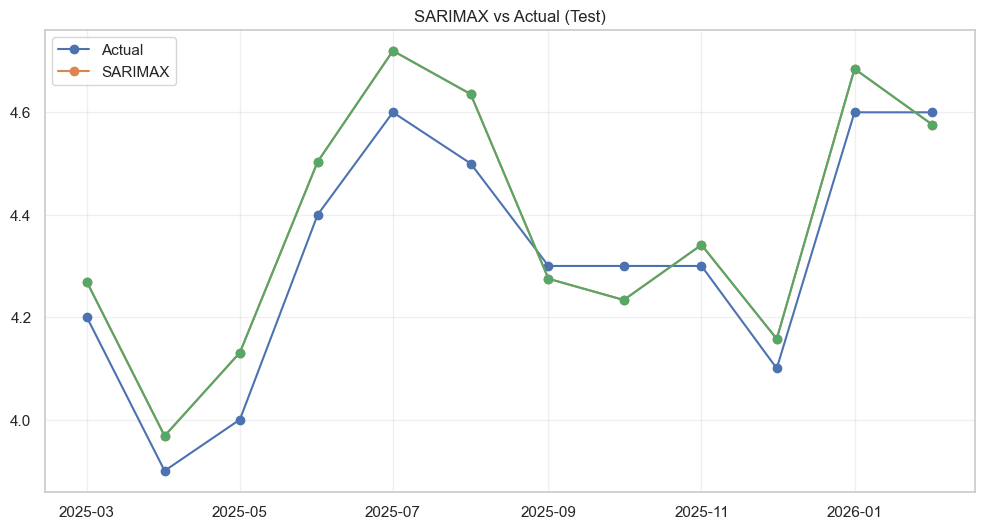

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(test_y.index, test_y, label="Actual", marker="o")

plt.plot(test_y.index, forecast_mean,
         label="SARIMAX", marker="o")

plt.plot(test_y.index, forecast_mean, marker="o")

plt.title("SARIMAX vs Actual (Test)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [31]:
## Lag variables 
df_lag = df2.copy()

df_lag["ICSA_L1"] = df_lag["ICSA"].shift(1)
df_lag["FEDFUNDS_L3"] = df_lag["FEDFUNDS"].shift(3)
df_lag["INDPRO_L6"] = df_lag["INDPRO"].shift(6)

df_lag = df_lag.dropna()

print(df_lag.shape)

(404, 9)


In [32]:
## split and test 
y = df_lag["UNRATENSA"]

X = df_lag[["ICSA_L1", "FEDFUNDS_L3", "INDPRO_L6"]]

train_y = y.iloc[:-12]
test_y = y.iloc[-12:]

train_X = X.iloc[:-12]
test_X = X.iloc[-12:]

In [33]:
## Fit SARIMAX with lagged predictors
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_lag = SARIMAX(
    train_y,
    exog=train_X,
    order=(1,0,0),
    seasonal_order=(1,0,0,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

result_lag = model_lag.fit()

print(result_lag.summary())

                                     SARIMAX Results                                      
Dep. Variable:                          UNRATENSA   No. Observations:                  392
Model:             SARIMAX(1, 0, 0)x(1, 0, 0, 12)   Log Likelihood                -441.081
Date:                            Thu, 12 Mar 2026   AIC                            894.163
Time:                                    18:08:55   BIC                            917.788
Sample:                                07-01-1992   HQIC                           903.538
                                     - 02-01-2025                                         
Covariance Type:                              opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
ICSA_L1     -9.542e-08   3.74e-08     -2.551      0.011   -1.69e-07   -2.21e-08
FEDFUNDS_L3    -0.1494      0.00

In [34]:
forecast_lag = result_lag.get_forecast(
    steps=12,
    exog=test_X
)

forecast_lag_mean = forecast_lag.predicted_mean

In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_lag = mean_absolute_error(test_y, forecast_lag_mean)
rmse_lag = np.sqrt(mean_squared_error(test_y, forecast_lag_mean))
mape_lag = np.mean(np.abs((test_y - forecast_lag_mean) / test_y)) * 100

print(mae_lag, rmse_lag, mape_lag)

0.05584113946348124 0.0690321102532278 1.2773297207965757


In [36]:
results_df.loc[len(results_df)] = [
    "SARIMAX_lag",
    mae_lag,
    rmse_lag,
    mape_lag
]

print(results_df)

            Model       MAE      RMSE      MAPE
0           Naive  0.233333  0.291548  5.627627
1  Seasonal Naive  0.250000  0.276887  5.915695
2          SARIMA  0.157080  0.177891  3.635925
3         SARIMAX  0.077182  0.085561  1.790930
4     SARIMAX_lag  0.055841  0.069032  1.277330


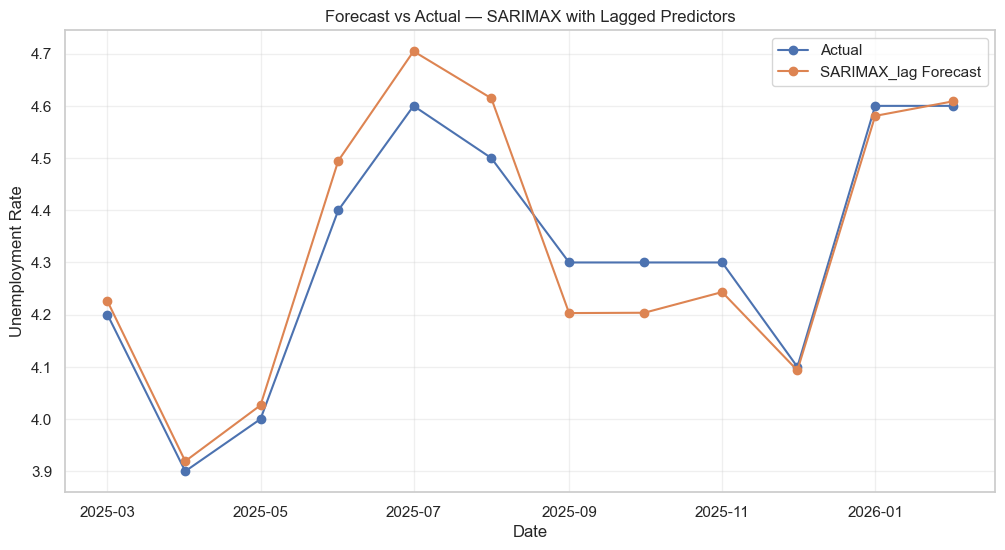

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(test_y.index, test_y,
         label="Actual",
         marker="o")

plt.plot(test_y.index, forecast_lag_mean,
         label="SARIMAX_lag Forecast",
         marker="o")

plt.title("Forecast vs Actual — SARIMAX with Lagged Predictors")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

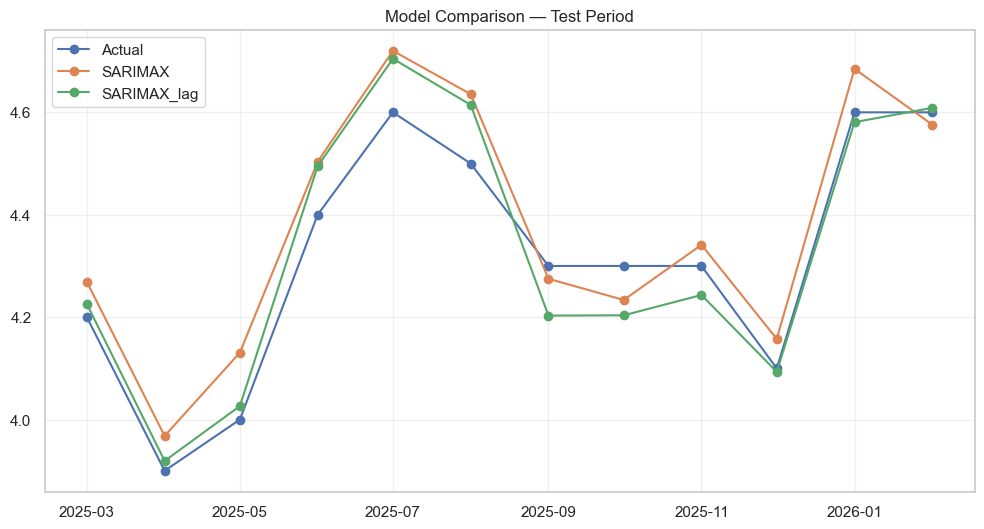

In [38]:
plt.figure(figsize=(12,6))

plt.plot(test_y.index, test_y,
         label="Actual",
         marker="o")

plt.plot(test_y.index, forecast_mean,
         label="SARIMAX",
         marker="o")

plt.plot(test_y.index, forecast_lag_mean,
         label="SARIMAX_lag",
         marker="o")

plt.title("Model Comparison — Test Period")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [39]:
## try different lags
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def run_sarimax_lag(l1, l2, l3):

    df_lag = df2.copy()

    df_lag["ICSA_L"] = df_lag["ICSA"].shift(l1)
    df_lag["FED_L"] = df_lag["FEDFUNDS"].shift(l2)
    df_lag["IND_L"] = df_lag["INDPRO"].shift(l3)

    df_lag = df_lag.dropna()

    y = df_lag["UNRATENSA"]
    X = df_lag[["ICSA_L", "FED_L", "IND_L"]]

    train_y = y.iloc[:-12]
    test_y = y.iloc[-12:]

    train_X = X.iloc[:-12]
    test_X = X.iloc[-12:]

    model = SARIMAX(
        train_y,
        exog=train_X,
        order=(1,0,0),
        seasonal_order=(1,0,0,12),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    result = model.fit(disp=False)

    forecast = result.get_forecast(
        steps=12,
        exog=test_X
    )

    pred = forecast.predicted_mean

    mae = mean_absolute_error(test_y, pred)
    rmse = np.sqrt(mean_squared_error(test_y, pred))
    mape = np.mean(np.abs((test_y - pred) / test_y)) * 100

    return mae, rmse, mape

In [40]:
tests = [
    (1,3,6),
    (1,6,3),
    (1,12,6),
    (3,6,6),
]

for t in tests:
    mae, rmse, mape = run_sarimax_lag(*t)
    print(t, mae, rmse, mape)

(1, 3, 6) 0.05584113946348124 0.0690321102532278 1.2773297207965757
(1, 6, 3) 0.09294686784381623 0.1129940994827937 2.1763828094147564
(1, 12, 6) 0.04712807993408156 0.06771894824242582 1.0990845176295756
(3, 6, 6) 0.07414307708143615 0.09422831620446395 1.7643479229674697


The best forecasting performance was obtained when jobless claims were lagged by one month, industrial production by six months, and the federal funds rate by twelve months, consistent with the delayed effect of monetary policy and economic activity on labor markets.

### did we plot it? what about the model performence? 
For the lag experiment section, you did report the lag comparison table, but you should add one compact table and one final plot for the best lagged SARIMAX, plus one comparison plot against the COVID dummy. Right now the experiment result is there numerically, but the section needs a cleaner “best model selected” ending.

### ML

In [41]:
## create data
df_ml = df2.copy()

df_ml["UN_L1"] = df_ml["UNRATENSA"].shift(1)
df_ml["UN_L12"] = df_ml["UNRATENSA"].shift(12)

df_ml["ICSA_L1"] = df_ml["ICSA"].shift(1)
df_ml["FED_L12"] = df_ml["FEDFUNDS"].shift(12)
df_ml["IND_L6"] = df_ml["INDPRO"].shift(6)

df_ml = df_ml.dropna()

print(df_ml.shape)

(398, 11)


In [42]:
y = df_ml["UNRATENSA"]

X = df_ml[
    ["UN_L1","UN_L12","ICSA_L1","FED_L12","IND_L6"]
]

train_y = y.iloc[:-12]
test_y = y.iloc[-12:]

train_X = X.iloc[:-12]
test_X = X.iloc[-12:]

In [43]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=0
)

rf.fit(train_X, train_y)

pred_rf = rf.predict(test_X)

In [44]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_rf = mean_absolute_error(test_y, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(test_y, pred_rf))
mape_rf = np.mean(np.abs((test_y - pred_rf)/test_y))*100

print(mae_rf, rmse_rf, mape_rf)

0.16383333333333294 0.2137864112370794 3.6887812535393647


## Testing covid Dummy 

In [45]:
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Start from common sample
df_covid = df2.copy()

# Best lag structure
df_covid["ICSA_L1"] = df_covid["ICSA"].shift(1)
df_covid["FED_L12"] = df_covid["FEDFUNDS"].shift(12)
df_covid["IND_L6"] = df_covid["INDPRO"].shift(6)

# COVID dummy: 1 during shock period, 0 otherwise
df_covid["COVID_DUMMY"] = 0
df_covid.loc[
    (df_covid.index >= "2020-03-01") & (df_covid.index <= "2021-12-01"),
    "COVID_DUMMY"
] = 1

# Drop NA created by lagging
df_covid = df_covid.dropna()

# Target and exogenous variables
y = df_covid["UNRATENSA"]
X = df_covid[["ICSA_L1", "FED_L12", "IND_L6", "COVID_DUMMY"]]

# Train / test split
train_y = y.iloc[:-12]
test_y = y.iloc[-12:]

train_X = X.iloc[:-12]
test_X = X.iloc[-12:]

# Fit final SARIMAX + COVID dummy
model_covid = SARIMAX(
    train_y,
    exog=train_X,
    order=(1, 0, 0),
    seasonal_order=(1, 0, 0, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

result_covid = model_covid.fit(disp=False)

print(result_covid.summary())

# Forecast
forecast_covid = result_covid.get_forecast(steps=12, exog=test_X)
pred_covid = forecast_covid.predicted_mean
ci_covid = forecast_covid.conf_int()

# Metrics
mae_covid = mean_absolute_error(test_y, pred_covid)
rmse_covid = np.sqrt(mean_squared_error(test_y, pred_covid))
mape_covid = np.mean(np.abs((test_y - pred_covid) / test_y)) * 100

print("\nSARIMAX + COVID Dummy")
print("MAE :", mae_covid)
print("RMSE:", rmse_covid)
print("MAPE:", mape_covid)

                                     SARIMAX Results                                      
Dep. Variable:                          UNRATENSA   No. Observations:                  386
Model:             SARIMAX(1, 0, 0)x(1, 0, 0, 12)   Log Likelihood                -420.020
Date:                            Fri, 13 Mar 2026   AIC                            854.039
Time:                                    12:22:05   BIC                            881.490
Sample:                                01-01-1993   HQIC                           864.940
                                     - 02-01-2025                                         
Covariance Type:                              opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
ICSA_L1      5.628e-08   6.13e-08      0.919      0.358   -6.38e-08    1.76e-07
FED_L12        -0.1291      0.08

Adding a COVID dummy variable did not improve forecasting performance. This suggests that the macroeconomic predictors already capture the impact of the pandemic, and the additional dummy variable increases model complexity without improving out-of-sample accuracy.

**Important forecasting lesson**

Dummy variables help when:

- forecasting the shock itself

- structural modeling

- causal analysis

Not always when:

- forecasting future periods after shock

- Your case = future period → dummy useless.

## Comparing:
- compare forcasting
- douple check your code
- build slides

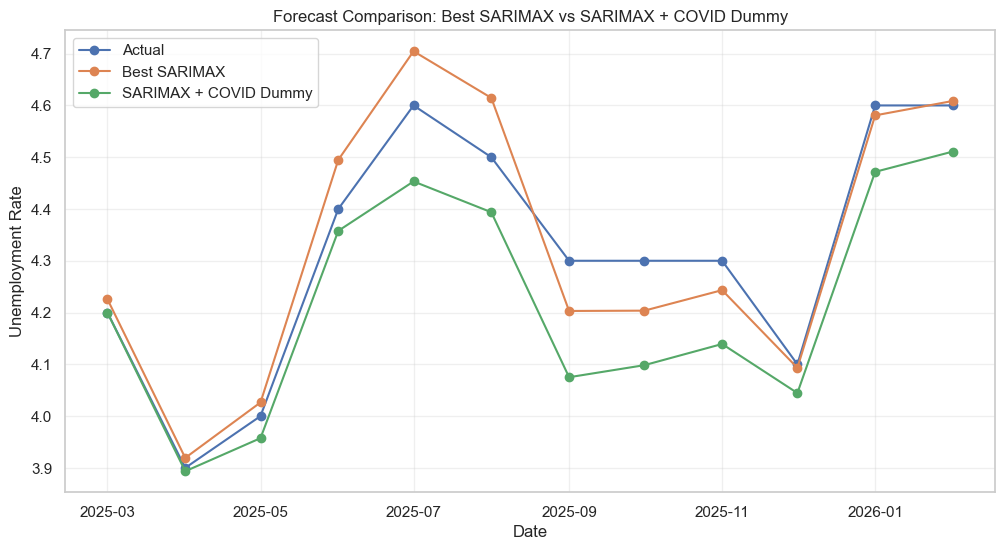

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

# Actual values
plt.plot(test_y.index, test_y, label="Actual", marker="o")

# Best lagged SARIMAX forecast
plt.plot(test_y.index, forecast_lag_mean, label="Best SARIMAX", marker="o")

# SARIMAX + COVID dummy forecast
plt.plot(test_y.index, pred_covid, label="SARIMAX + COVID Dummy", marker="o")

plt.title("Forecast Comparison: Best SARIMAX vs SARIMAX + COVID Dummy")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


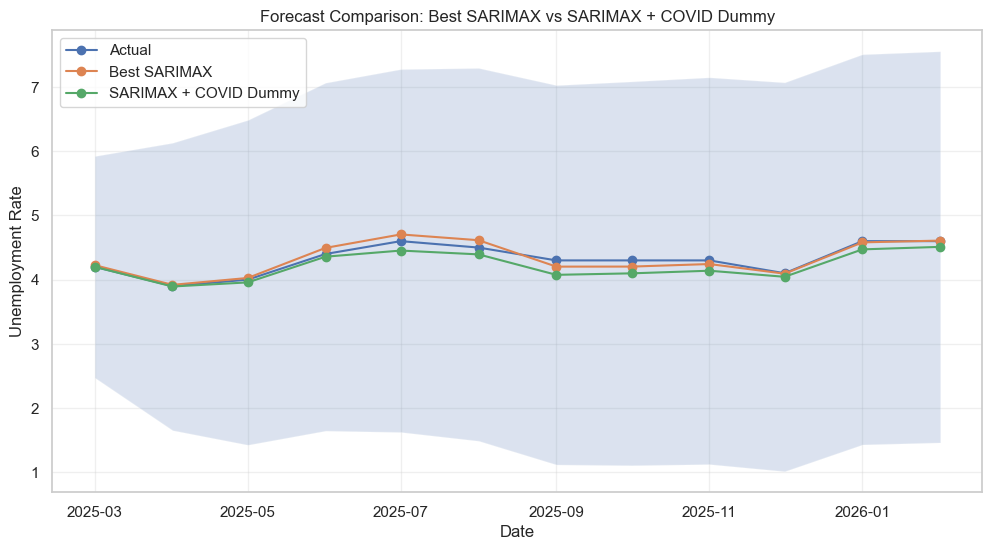

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(test_y.index, test_y, label="Actual", marker="o")
plt.plot(test_y.index, forecast_lag_mean, label="Best SARIMAX", marker="o")
plt.plot(test_y.index, pred_covid, label="SARIMAX + COVID Dummy", marker="o")

plt.fill_between(
    forecast_covid.conf_int().index,
    forecast_covid.conf_int().iloc[:, 0],
    forecast_covid.conf_int().iloc[:, 1],
    alpha=0.2
)

plt.title("Forecast Comparison: Best SARIMAX vs SARIMAX + COVID Dummy")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
